In [35]:
import os
import numpy as np
import polars as pl
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [36]:
start_year = 2024
end_year = 2024
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep5_mratio5_maxsamp25000_drug_reaction_associations.csv'

In [37]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction_name'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna(subset=['uncorrected_a'])
preds.head()

,drug_id,drug_name_x,reaction_id,reaction_name,patient_sex,replicate,a,b,c,d,...,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_PRR,uncorrected_OR,uncorrected_PHI,reaction,mean,prr_diff
9,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,0.0,218,753,11,2779,...,219.0,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-2.014510
89,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,0.0,135,836,6,2784,...,137.0,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,0.139032,-2.019879
119,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,1.0,218,753,8,2789,...,219.0,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-1.693550
196,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,1.0,135,836,6,2791,...,137.0,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,0.139032,-2.017373
229,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,2.0,218,753,8,2801,...,219.0,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-1.689269


In [38]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()
# fn = '../data/onsides_v3_0_0_high_confidence_mapped.csv'
# positive_df = pd.read_csv(fn)
# positive_df['meddra_name'] = positive_df['meddra_name'].str.lower()
# positive_df.rename(columns={'meddra_name': 'reaction', 'rxnorm_name': 'drug'}, inplace=True)
# positive_df['label'] = 1
# positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [39]:
# negative controls
negative_files = [f for f in os.listdir(f'../results/{start_year}-{end_year}') if f.endswith(f"confounded_examples.csv")]
negative_files
negative_df = None
for fn in negative_files:
    df = pd.read_csv(os.path.join('../', 'results', f'{start_year}-{end_year}', fn))
    if negative_df is None:
        negative_df = df
    else:
        negative_df = pd.concat([negative_df, df])

negative_df['reaction'] = negative_df['reaction_name'].str.lower()
negative_df['drug_name'] = negative_df['drug_name'].str.lower()
negative_df['label'] = 0
negative_df.head()
negative_df.info()
columns_to_check = ['drug_name','sex', 'conf_drug_name', 'age']

for col in columns_to_check:
    all_nan = negative_df[col].isna().all()
    print(f"All rows in '{col}' are NaN? {all_nan}")

negative_df[columns_to_check].notna().sum()
negative_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 539974 entries, 0 to 1859
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   indication      74324 non-null   object 
 1   reaction_name   539974 non-null  object 
 2   drug_id         539974 non-null  int64  
 3   PHI_conf_drug   539974 non-null  float64
 4   PRR_drug_rea    539974 non-null  float64
 5   drug_name       539974 non-null  object 
 6   sex             3935 non-null    float64
 7   conf_drug_name  459855 non-null  object 
 8   age             1860 non-null    object 
 9   reaction        539974 non-null  object 
 10  label           539974 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 49.4+ MB
All rows in 'drug_name' are NaN? False
All rows in 'sex' are NaN? False
All rows in 'conf_drug_name' are NaN? False
All rows in 'age' are NaN? False


,indication,reaction_name,drug_id,PHI_conf_drug,PRR_drug_rea,drug_name,sex,conf_drug_name,age,reaction,label
0,Prader-Willi syndrome,Expired device used,241975,0.109896,213.134192,genotropin,NaN,NaN,NaN,expired device used,0
1,Prader-Willi syndrome,Device information output issue,241975,0.109896,1661.913607,genotropin,NaN,NaN,NaN,device information output issue,0
2,Prader-Willi syndrome,Poor quality device used,241975,0.109896,691.927100,genotropin,NaN,NaN,NaN,poor quality device used,0
3,Choroidal neovascularisation,Vitritis,2591588,0.226595,374.205877,vabysmo,NaN,NaN,NaN,vitritis,0
4,Choroidal neovascularisation,Vitritis,2591594,0.226595,374.205877,vabysmo,NaN,NaN,NaN,vitritis,0


In [40]:
# positive controls: use pt_meddra_id as drug_id
positive_df['drug_name'] = positive_df['drug']
positive_df['reaction'] = positive_df['reaction'].str.lower()
positive_df['label'] = 1

# negative controls
negative_df['reaction'] = negative_df['reaction_name'].str.lower()
negative_df['label'] = 0

# unify columns: drug_id, reaction, label
reference = pd.concat([
    positive_df[['drug_name', 'reaction', 'label']],
    negative_df[['drug_name', 'reaction', 'label']]
], ignore_index=True)
reference.head()

# ensure numeric type for intersections
#ref_drugs = set(reference.drug_id.dropna().astype(int).unique())
#pred_drugs = set(preds.drug_id.dropna().astype(int).unique())
#len(pred_drugs), len(ref_drugs), len(pred_drugs & ref_drugs)


,drug_name,reaction,label
0,escitalopram,delirium,1
1,ponatinib,atrial tachycardia,1
2,fluoxetine,lymphadenopathy,1
3,"estrogens, conjugated (USP)",fluid retention,1
4,sapropterin,psychomotor hyperactivity,1


In [41]:
pred_reactions = set(preds.reaction.unique())
ref_reactions = set(reference.reaction.unique())
len(pred_reactions), len(ref_reactions), len(pred_reactions&ref_reactions)

(791, 2165, 568)

In [42]:
preds['drug_name'] = preds['drug_name_x'].str.lower()
preds.head()

,drug_id,drug_name_x,reaction_id,reaction_name,patient_sex,replicate,a,b,c,d,...,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_PRR,uncorrected_OR,uncorrected_PHI,reaction,mean,prr_diff,drug_name
9,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,0.0,218,753,11,2779,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-2.014510,lidocaine hydrochloride
89,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,0.0,135,836,6,2784,...,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,0.139032,-2.019879,lidocaine hydrochloride
119,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,1.0,218,753,8,2789,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-1.693550,lidocaine hydrochloride
196,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,1.0,135,836,6,2791,...,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,0.139032,-2.017373,lidocaine hydrochloride
229,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,2.0,218,753,8,2801,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,0.224511,-1.689269,lidocaine hydrochloride


In [43]:
rep = 1
preds_rep = preds[preds['replicate'] == rep]
preds_small = preds_rep[['drug_name', 'reaction','prr_diff','mean','PRR']]
chunk_size = 100_000
results = []

for start in range(0, len(reference), chunk_size):
    ref_chunk = reference.iloc[start:start+chunk_size]
    merged_chunk = pd.merge(preds_small, ref_chunk, on=['drug_name', 'reaction'], how='inner')
    results.append(merged_chunk)

merged = pd.concat(results, ignore_index=True)
merged.label.sum(), len(merged.label)

(np.int64(11360), 8698131)

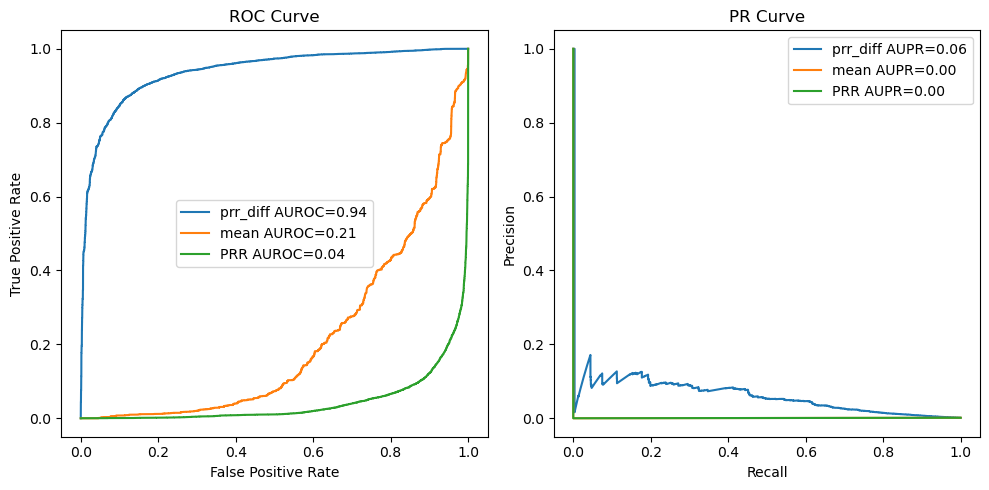

In [44]:
col = 'prr_diff'

plt.figure(figsize=(10,5))

for col in ('prr_diff', 'mean', 'PRR'):
    auroc = metrics.roc_auc_score(merged['label'], merged[col])
    aupr = metrics.average_precision_score(merged['label'], merged[col])
    fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"{col} AUROC={auroc:.2f}")
    
    pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
    plt.subplot(1,2,2)
    plt.plot(re, pr, label=f"{col} AUPR={aupr:.2f}")

plt.subplot(1,2,1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1,2,2)
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/confounding_performance_roc_pr_curves.pdf')

In [45]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
col, neg.mean(), pos.mean()

('PRR', np.float64(28.051538790095723), np.float64(3.473820389425103))

In [52]:
merged['label'].value_counts()


label
0    8686771
1      11360
Name: count, dtype: int64

In [47]:
merged.groupby('label')[col].mean()


label
0    28.051539
1     3.473820
Name: PRR, dtype: float64

In [48]:
merged[col].nunique()
merged[col].isna().sum()


np.int64(0)

In [49]:
aupr = metrics.average_precision_score(merged['label'], merged[col])
print(f"{col} AUPR = {aupr:.6f}")


PRR AUPR = 0.000659


In [50]:
merged.head()

,drug_name,reaction,prr_diff,mean,PRR,label
0,gemcitabine,thrombocytopenia,-1.654798,0.076744,3.019278,1
1,gemcitabine,anaemia,-0.666873,0.046512,3.863049,1
2,gemcitabine,neutropenia,-1.064423,0.055814,2.528541,1
3,gemcitabine,thrombocytopenia,-1.654798,0.076744,3.019278,1
4,gemcitabine,anaemia,-0.666873,0.046512,3.863049,1


In [51]:
from sklearn import metrics

score_cols = ['prr_diff', 'mean', 'PRR']

for col in score_cols:
    y_true = merged['label']
    y_score = merged[col]
    
    auroc = metrics.roc_auc_score(y_true, y_score)
    aupr = metrics.average_precision_score(y_true, y_score)
    
    print(f"{col}:")
    print(f"  AUROC = {auroc:.6f}")
    print(f"  AUPR  = {aupr:.8f}")
    print()


prr_diff:
  AUROC = 0.938880
  AUPR  = 0.06037750

mean:
  AUROC = 0.209895
  AUPR  = 0.00074963

PRR:
  AUROC = 0.043586
  AUPR  = 0.00065918

